In [1]:

print("AI Smart Travel Risk & Route Intelligence System")
print("Machine Learning Notebook")

AI Smart Travel Risk & Route Intelligence System
Machine Learning Notebook


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
file_path = "../data/US_Accidents_March23.csv/US_Accidents_March23.csv"

df = pd.read_csv(file_path, nrows=100000)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 46)


In [4]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [5]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [6]:
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  100000
End_Lng                  100000
Distance(mi)                  0
Description                   0
Street                        0
City                          1
County                        0
State                         0
Zipcode                       7
Country                       0
Timezone                      7
Airport_Code                  7
Weather_Timestamp          1054
Temperature(F)             1591
Wind_Chill(F)             95678
Humidity(%)                1856
Pressure(in)               1292
Visibility(mi)             1846
Wind_Direction             1064
Wind_Speed(mph)           23820
Precipitation(in)         92632
Weather_Condition          1604
Amenity                       0
Bump                          0
Crossing

In [7]:
df["Severity"].value_counts()

Severity
2    55025
3    44844
1       98
4       33
Name: count, dtype: int64

In [8]:
df["Severity"].value_counts(normalize=True) * 100

Severity
2    55.025
3    44.844
1     0.098
4     0.033
Name: proportion, dtype: float64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  str    
 1   Source                 100000 non-null  str    
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  str    
 4   End_Time               100000 non-null  str    
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  str    
 11  Street                 100000 non-null  str    
 12  City                   99999 non-null   str    
 13  County                 100000 non-null  str    
 14  State                  100000 non-null  str    


In [10]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,100000.000000,100000.000000,100000.000000,0.0,0.0,100000.000000,98409.000000,4322.000000,98144.000000,98708.000000,98154.000000,76180.000000,7368.000000
mean,2.448120,35.630369,-119.322756,NaN,NaN,0.011345,66.641262,48.845812,59.794170,29.961021,9.338639,8.044165,0.025786
std,0.499931,2.101259,3.663525,NaN,NaN,0.262244,12.703846,19.898270,23.184442,0.275672,1.885828,4.298926,0.051695
min,1.000000,32.542587,-123.813927,NaN,NaN,0.000000,3.200000,-8.400000,4.000000,2.980000,0.100000,0.000000,0.000000
25%,2.000000,33.957775,-121.828468,NaN,NaN,0.000000,57.900000,37.100000,43.000000,29.890000,10.000000,4.600000,0.000000
50%,2.000000,34.168579,-118.384232,NaN,NaN,0.000000,66.000000,42.500000,62.000000,29.970000,10.000000,6.900000,0.000000
75%,3.000000,37.776682,-117.916023,NaN,NaN,0.010000,75.000000,63.000000,78.000000,30.060000,10.000000,10.400000,0.030000
max,4.000000,41.428753,-81.550728,NaN,NaN,51.130000,114.100000,107.000000,100.000000,33.040000,80.000000,241.700000,0.550000


In [6]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])

df["Hour"] = df["Start_Time"].dt.hour
df["Day_of_Week"] = df["Start_Time"].dt.dayofweek
df["Month"] = df["Start_Time"].dt.month
df["Is_Weekend"] = df["Day_of_Week"].isin([5, 6])

df[["Start_Time", "Hour", "Day_of_Week", "Month", "Is_Weekend"]].head()

,Start_Time,Hour,Day_of_Week,Month,Is_Weekend
0,2016-02-08 05:46:00,5,0,2,False
1,2016-02-08 06:07:59,6,0,2,False
2,2016-02-08 06:49:27,6,0,2,False
3,2016-02-08 07:23:34,7,0,2,False
4,2016-02-08 07:39:07,7,0,2,False


In [12]:
df["Is_Weekend"] = df["Day_of_Week"].isin([5, 6])

df[["Start_Time", "Day_of_Week", "Is_Weekend"]].head(10)

,Start_Time,Day_of_Week,Is_Weekend
0,2016-02-08 05:46:00,0,False
1,2016-02-08 06:07:59,0,False
2,2016-02-08 06:49:27,0,False
3,2016-02-08 07:23:34,0,False
4,2016-02-08 07:39:07,0,False
5,2016-02-08 07:44:26,0,False
6,2016-02-08 07:59:35,0,False
7,2016-02-08 07:59:58,0,False
8,2016-02-08 08:00:40,0,False
9,2016-02-08 08:10:04,0,False


In [7]:
features = [
    "Start_Lat",
    "Start_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Hour",
    "Day_of_Week",
    "Month",
    "Is_Weekend",
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal"
]

X = df[features]
y = df["Severity"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 23)
Target shape: (100000,)


In [14]:
X.isnull().sum()

Start_Lat              0
Start_Lng              0
Distance(mi)           0
Temperature(F)      1591
Humidity(%)         1856
Pressure(in)        1292
Visibility(mi)      1846
Wind_Speed(mph)    23820
Hour                   0
Day_of_Week            0
Month                  0
Is_Weekend             0
Amenity                0
Bump                   0
Crossing               0
Give_Way               0
Junction               0
Railway                0
Roundabout             0
Station                0
Stop                   0
Traffic_Calming        0
Traffic_Signal         0
dtype: int64

In [8]:
numeric_features = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)"
]

for column in numeric_features:
    X[column] = X[column].fillna(X[column].median())

print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
Start_Lat          0
Start_Lng          0
Distance(mi)       0
Temperature(F)     0
Humidity(%)        0
Pressure(in)       0
Visibility(mi)     0
Wind_Speed(mph)    0
Hour               0
Day_of_Week        0
Month              0
Is_Weekend         0
Amenity            0
Bump               0
Crossing           0
Give_Way           0
Junction           0
Railway            0
Roundabout         0
Station            0
Stop               0
Traffic_Calming    0
Traffic_Signal     0
dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (80000, 23)
Testing features: (20000, 23)
Training target: (80000,)
Testing target: (20000,)


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [18]:
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [19]:
y_pred = rf_model.predict(X_test)

print("Predictions completed successfully!")
print("Number of predictions:", len(y_pred))

Predictions completed successfully!
Number of predictions: 20000


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7946
Accuracy (%): 79.46


In [21]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        20
           2       0.85      0.77      0.80     11005
           3       0.74      0.83      0.78      8969
           4       0.00      0.00      0.00         6

    accuracy                           0.79     20000
   macro avg       0.40      0.40      0.40     20000
weighted avg       0.80      0.79      0.79     20000



D:\AI-Smart-Travel-Risk\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\AI-Smart-Travel-Risk\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\AI-Smart-Travel-Risk\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [22]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[   0   14    6    0]
 [   0 8442 2563    0]
 [   0 1519 7450    0]
 [   0    2    4    0]]


In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
1         Start_Lng    0.153554
0         Start_Lat    0.139603
8              Hour    0.105812
3    Temperature(F)    0.099898
5      Pressure(in)    0.092358
4       Humidity(%)    0.092078
10            Month    0.068715
7   Wind_Speed(mph)    0.068513
9       Day_of_Week    0.050057
6    Visibility(mi)    0.025697
2      Distance(mi)    0.020199
14         Crossing    0.018500
22   Traffic_Signal    0.015759
20             Stop    0.015547
16         Junction    0.015313
11       Is_Weekend    0.008748
19          Station    0.004560
12          Amenity    0.002925
17          Railway    0.001319
15         Give_Way    0.000768
21  Traffic_Calming    0.000050
13             Bump    0.000023
18       Roundabout    0.000003


In [24]:
# Select features for K-Means clustering

cluster_features = [
    "Start_Lat",
    "Start_Lng",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Distance(mi)",
    "Hour",
    "Day_of_Week",
    "Month"
]

X_cluster = X[cluster_features]

print("Clustering features selected successfully!")
print("Shape:", X_cluster.shape)
print("Features:")
print(X_cluster.columns.tolist())

Clustering features selected successfully!
Shape: (100000, 11)
Features:
['Start_Lat', 'Start_Lng', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Distance(mi)', 'Hour', 'Day_of_Week', 'Month']


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Features scaled successfully!")
print("Scaled shape:", X_cluster_scaled.shape)

Features scaled successfully!
Scaled shape: (100000, 11)


In [26]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

print("Elbow Method calculation completed!")
print("Inertia values:", inertia)

Elbow Method calculation completed!
Inertia values: [966680.3148590357, 882204.7157628622, 808061.9615562636, 745029.2835908842, 707009.8125898038, 647086.9465269968, 610939.0678963797]


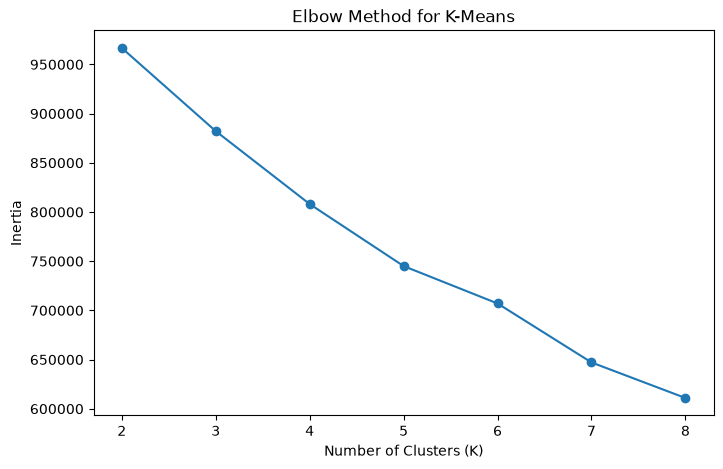

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 9), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette scores:")
for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K={k}: {score:.4f}")

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import silhouette_score

# Take only 2,000 rows for the silhouette calculation
X_sample = X_cluster_scaled[:2000]

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

print("Silhouette scores:")

for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K={k}: {score:.4f}")

In [15]:
# Create final K-Means model

kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

print("K-Means model trained successfully!")
print("Number of clusters:", len(set(cluster_labels)))

K-Means model trained successfully!
Number of clusters: 2


In [16]:
joblib.dump(kmeans_model, "../models/kmeans.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("K-Means model and scaler saved successfully!")

K-Means model and scaler saved successfully!


In [17]:
print("Checking route data...")

print("routes:", "exists" if "routes" in globals() else "missing")
print("route1_points:", "exists" if "route1_points" in globals() else "missing")
print("route2_points:", "exists" if "route2_points" in globals() else "missing")

Checking route data...
routes: missing
route1_points: missing
route2_points: missing


In [19]:
import requests

GRAPHOPPER_API_KEY = "e098b51a-cfd1-40c5-b076-fef6ea40dfd9"

source = (-118.2437, 34.0522)
destination = (-117.1611, 32.7157)

url = "https://graphhopper.com/api/1/route"

params = {
    "point": [
        f"{source[1]},{source[0]}",
        f"{destination[1]},{destination[0]}"
    ],
    "profile": "car",
    "algorithm": "alternative_route",
    "alternative_route.max_paths": 3,
    "alternative_route.max_weight_factor": 1.6,
    "alternative_route.max_share_factor": 0.6,
    "locale": "en",
    "calc_points": "true",
    "points_encoded": "false",
    "key": GRAPHOPPER_API_KEY
}

response = requests.get(url, params=params)
route_data = response.json()

routes = route_data["paths"]

print("Number of routes:", len(routes))

Number of routes: 2


In [20]:
route_candidates = []

for route_number, route in enumerate(routes, start=1):
    coordinates = route["points"]["coordinates"]

    indices = np.linspace(
        0,
        len(coordinates) - 1,
        50,
        dtype=int
    )

    sampled_points = [coordinates[i] for i in indices]

    route_df = pd.DataFrame(
        sampled_points,
        columns=["Longitude", "Latitude"]
    )

    route_df["Route"] = route_number

    route_candidates.append(route_df)

route1_points = route_candidates[0]
route2_points = route_candidates[1]

print("Route 1 points:", route1_points.shape)
print("Route 2 points:", route2_points.shape)

Route 1 points: (50, 3)
Route 2 points: (50, 3)


In [23]:
def calculate_historical_risk(route_df, accidents_df, radius_km=1):

    result = route_df.copy()
    accident_counts = []
    severity_values = []

    for _, point in result.iterrows():

        distances = accidents_df.apply(
            lambda row: haversine_distance(
                point["Latitude"],
                point["Longitude"],
                row["Start_Lat"],
                row["Start_Lng"]
            ),
            axis=1
        )

        nearby = accidents_df[distances <= radius_km]

        accident_counts.append(len(nearby))

        if len(nearby) > 0:
            severity_values.append(nearby["Severity"].mean())
        else:
            severity_values.append(0)

    result["Accidents_1km"] = accident_counts
    result["Severity_1km"] = severity_values

    return result


route1_risk = calculate_historical_risk(route1_points, df)
route2_risk = calculate_historical_risk(route2_points, df)

print("Route 1 risk points:", route1_risk.shape)
print("Route 2 risk points:", route2_risk.shape)

Route 1 risk points: (50, 5)
Route 2 risk points: (50, 5)


In [24]:
print("ROUTE 1")
print("Average Accidents within 1km:",
      route1_risk["Accidents_1km"].mean())
print("Average Severity:",
      route1_risk["Severity_1km"].mean())

print("\nROUTE 2")
print("Average Accidents within 1km:",
      route2_risk["Accidents_1km"].mean())
print("Average Severity:",
      route2_risk["Severity_1km"].mean())

ROUTE 1
Average Accidents within 1km: 62.04
Average Severity: 2.8645023149636266

ROUTE 2
Average Accidents within 1km: 53.48
Average Severity: 2.683237594898754


In [25]:
features = [
    "Start_Lat","Start_Lng","Distance(mi)","Temperature(F)",
    "Humidity(%)","Pressure(in)","Visibility(mi)",
    "Wind_Speed(mph)","Hour","Day_of_Week","Month",
    "Is_Weekend","Amenity","Bump","Crossing","Give_Way",
    "Junction","Railway","Roundabout","Station","Stop",
    "Traffic_Calming","Traffic_Signal"
]

def build_route_ml_features(route_risk_df, accidents_df):

    route_features = []

    for _, point in route_risk_df.iterrows():

        distances = accidents_df.apply(
            lambda row: haversine_distance(
                point["Latitude"],
                point["Longitude"],
                row["Start_Lat"],
                row["Start_Lng"]
            ),
            axis=1
        )

        nearby = accidents_df[distances <= 1]

        if len(nearby) == 0:
            continue

        feature_row = {
            "Start_Lat": point["Latitude"],
            "Start_Lng": point["Longitude"],
            "Distance(mi)": nearby["Distance(mi)"].median(),
            "Temperature(F)": nearby["Temperature(F)"].median(),
            "Humidity(%)": nearby["Humidity(%)"].median(),
            "Pressure(in)": nearby["Pressure(in)"].median(),
            "Visibility(mi)": nearby["Visibility(mi)"].median(),
            "Wind_Speed(mph)": nearby["Wind_Speed(mph)"].median(),
            "Hour": nearby["Hour"].mode()[0],
            "Day_of_Week": nearby["Day_of_Week"].mode()[0],
            "Month": nearby["Month"].mode()[0],
            "Is_Weekend": nearby["Is_Weekend"].mode()[0],
            "Amenity": nearby["Amenity"].mean(),
            "Bump": nearby["Bump"].mean(),
            "Crossing": nearby["Crossing"].mean(),
            "Give_Way": nearby["Give_Way"].mean(),
            "Junction": nearby["Junction"].mean(),
            "Railway": nearby["Railway"].mean(),
            "Roundabout": nearby["Roundabout"].mean(),
            "Station": nearby["Station"].mean(),
            "Stop": nearby["Stop"].mean(),
            "Traffic_Calming": nearby["Traffic_Calming"].mean(),
            "Traffic_Signal": nearby["Traffic_Signal"].mean()
        }

        route_features.append(feature_row)

    return pd.DataFrame(route_features)


route1_ml_features = build_route_ml_features(route1_risk, df)
route2_ml_features = build_route_ml_features(route2_risk, df)

print("Route 1 ML features:", route1_ml_features.shape)
print("Route 2 ML features:", route2_ml_features.shape)

Route 1 ML features: (50, 23)
Route 2 ML features: (50, 23)


In [26]:
def calculate_rf_risk(route_ml_features):

    probabilities = rf_model.predict_proba(
        route_ml_features[features]
    )

    expected_severity = []

    for probability in probabilities:
        expected = sum(
            severity * prob
            for severity, prob in zip(
                rf_model.classes_,
                probability
            )
        )
        expected_severity.append(expected)

    result = route_ml_features.copy()

    result["Expected_Severity"] = expected_severity

    result["RF_Risk_Score"] = (
        (result["Expected_Severity"] - 1) / 3
    ) * 100

    return result


route1_rf = calculate_rf_risk(route1_ml_features)
route2_rf = calculate_rf_risk(route2_ml_features)

print("Route 1 Average RF Risk:",
      round(route1_rf["RF_Risk_Score"].mean(), 2))

print("Route 2 Average RF Risk:",
      round(route2_rf["RF_Risk_Score"].mean(), 2))

Route 1 Average RF Risk: 55.49
Route 2 Average RF Risk: 52.39


In [27]:
# Common normalization for both routes
all_route_points = pd.concat(
    [route1_risk, route2_risk],
    ignore_index=True
)

min_accidents = all_route_points["Accidents_1km"].min()
max_accidents = all_route_points["Accidents_1km"].max()

all_route_points["Accident_Density_Score"] = (
    (all_route_points["Accidents_1km"] - min_accidents)
    / (max_accidents - min_accidents)
) * 100

all_route_points["Severity_Score"] = (
    (all_route_points["Severity_1km"] - 1) / 3
) * 100

all_route_points["Historical_Risk_Score"] = (
    all_route_points["Accident_Density_Score"] * 0.5
    + all_route_points["Severity_Score"] * 0.5
)

route1_risk = all_route_points[
    all_route_points["Route"] == 1
].copy()

route2_risk = all_route_points[
    all_route_points["Route"] == 2
].copy()

route1_avg_historical = route1_risk["Historical_Risk_Score"].mean()
route2_avg_historical = route2_risk["Historical_Risk_Score"].mean()

route1_avg_rf = route1_rf["RF_Risk_Score"].mean()
route2_avg_rf = route2_rf["RF_Risk_Score"].mean()

route1_final_risk = (
    route1_avg_historical * 0.5
    + route1_avg_rf * 0.5
)

route2_final_risk = (
    route2_avg_historical * 0.5
    + route2_avg_rf * 0.5
)

print("Route 1 Final Safety Risk:",
      round(route1_final_risk, 2))

print("Route 2 Final Safety Risk:",
      round(route2_final_risk, 2))

Route 1 Final Safety Risk: 47.5
Route 2 Final Safety Risk: 43.85


In [28]:
route1_distance = routes[0]["distance"] / 1000
route2_distance = routes[1]["distance"] / 1000

route1_time = routes[0]["time"] / 60000
route2_time = routes[1]["time"] / 60000

# Convert risk into safety score
route1_safety = 100 - route1_final_risk
route2_safety = 100 - route2_final_risk

# Fastest route gets 100 time score
fastest_time = min(route1_time, route2_time)

route1_time_score = (fastest_time / route1_time) * 100
route2_time_score = (fastest_time / route2_time) * 100

# Final score: 70% safety + 30% travel time
route1_final_score = (
    route1_safety * 0.70
    + route1_time_score * 0.30
)

route2_final_score = (
    route2_safety * 0.70
    + route2_time_score * 0.30
)

print("ROUTE 1")
print("Distance:", round(route1_distance, 2), "km")
print("Travel Time:", round(route1_time, 2), "minutes")
print("Safety Score:", round(route1_safety, 2))
print("Final Score:", round(route1_final_score, 2))

print("\nROUTE 2")
print("Distance:", round(route2_distance, 2), "km")
print("Travel Time:", round(route2_time, 2), "minutes")
print("Safety Score:", round(route2_safety, 2))
print("Final Score:", round(route2_final_score, 2))

if route1_final_score > route2_final_score:
    print("\nRecommended Route: Route 1")
else:
    print("\nRecommended Route: Route 2")

ROUTE 1
Distance: 193.66 km
Travel Time: 120.19 minutes
Safety Score: 52.5
Final Score: 66.75

ROUTE 2
Distance: 229.99 km
Travel Time: 137.03 minutes
Safety Score: 56.15
Final Score: 65.62

Recommended Route: Route 1


In [29]:
import os

os.makedirs("../models/route_results", exist_ok=True)

route1_risk.to_csv(
    "../models/route_results/route1_historical_risk.csv",
    index=False
)

route2_risk.to_csv(
    "../models/route_results/route2_historical_risk.csv",
    index=False
)

route1_rf.to_csv(
    "../models/route_results/route1_rf_risk.csv",
    index=False
)

route2_rf.to_csv(
    "../models/route_results/route2_rf_risk.csv",
    index=False
)

print("Route risk results saved successfully! ✅")

Route risk results saved successfully! ✅


In [30]:
import pandas as pd

final_route_summary = pd.DataFrame({
    "Route": ["Route 1", "Route 2"],
    "Distance_km": [route1_distance, route2_distance],
    "Travel_Time_min": [route1_time, route2_time],
    "Safety_Score": [route1_safety, route2_safety],
    "Final_Score": [route1_final_score, route2_final_score],
    "Recommended": [
        route1_final_score > route2_final_score,
        route2_final_score > route1_final_score
    ]
})

final_route_summary.to_csv(
    "../models/route_results/final_route_summary.csv",
    index=False
)

print(final_route_summary)
print("\nFinal route summary saved successfully! ✅")

     Route  Distance_km  Travel_Time_min  Safety_Score  Final_Score  \
0  Route 1   193.658742       120.194217     52.503678    66.752574   
1  Route 2   229.986219       137.032767     56.152044    65.620039   

   Recommended  
0         True  
1        False  

Final route summary saved successfully! ✅


In [22]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

print("Haversine function ready!")

Haversine function ready!


In [ ]:
print("Cluster distribution:")

print(pd.Series(cluster_labels).value_counts().sort_index())

In [ ]:
# Add cluster labels to the data

cluster_df = X_cluster.copy()
cluster_df["Cluster"] = cluster_labels
cluster_df["Severity"] = y.values

# Average severity for each cluster

print("Average severity by cluster:")
print(cluster_df.groupby("Cluster")["Severity"].mean())

In [ ]:
cluster_summary = cluster_df.groupby("Cluster").agg({
    "Severity": "mean",
    "Temperature(F)": "mean",
    "Humidity(%)": "mean",
    "Visibility(mi)": "mean",
    "Wind_Speed(mph)": "mean",
    "Distance(mi)": "mean",
    "Hour": "mean",
    "Day_of_Week": "mean",
    "Month": "mean"
})

print(cluster_summary)

In [ ]:
severity_distribution = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Severity"],
    normalize="index"
) * 100

print("Severity distribution within each cluster:")
print(severity_distribution.round(2))

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_df["Start_Lng"],
    cluster_df["Start_Lat"],
    c=cluster_df["Cluster"],
    s=5,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Accident Clusters")
plt.show()

In [ ]:
print(cluster_df.groupby("Cluster")[["Start_Lat", "Start_Lng"]].mean())

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=5,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in 2D PCA Space")

plt.show()

In [ ]:
cluster_risk = cluster_df.groupby("Cluster")["Severity"].mean()

print("Cluster Risk Scores:")
print(cluster_risk)

In [ ]:
min_severity = cluster_risk.min()
max_severity = cluster_risk.max()

cluster_risk_score = (
    (cluster_risk - min_severity)
    / (max_severity - min_severity)
) * 100

print("Cluster Risk Scores (0-100):")
print(cluster_risk_score)

In [ ]:
cluster_percentage = (
    cluster_df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Cluster Percentage:")
print(cluster_percentage.round(2))

In [ ]:
sample = X_test.iloc[[0]]

probabilities = rf_model.predict_proba(sample)

print("Severity probabilities:")
print(probabilities)

In [ ]:
print("Severity classes:")
print(rf_model.classes_)

In [ ]:
severity_probabilities = probabilities[0]

expected_severity = sum(
    severity * probability
    for severity, probability
    in zip(rf_model.classes_, severity_probabilities)
)

print("Expected Severity:", round(expected_severity, 2))

In [ ]:
severity_risk_score = (
    (expected_severity - 1) / (4 - 1)
) * 100

print("Severity Risk Score:", round(severity_risk_score, 2))

In [ ]:
sample_scaled = scaler.transform(sample[cluster_features])

sample_cluster = kmeans_model.predict(sample_scaled)

print("Predicted Cluster:", sample_cluster[0])

In [ ]:
cluster_avg_severity = cluster_risk[sample_cluster[0]]

cluster_risk_score = (
    (cluster_avg_severity - 1) / (4 - 1)
) * 100

print("Cluster Average Severity:", round(cluster_avg_severity, 2))
print("Cluster Risk Score:", round(cluster_risk_score, 2))

In [ ]:
final_risk_score = (
    severity_risk_score + cluster_risk_score
) / 2

print("Final Risk Score:", round(final_risk_score, 2))

In [ ]:
def calculate_risk(input_data):

    # -----------------------------
    # 1. Random Forest prediction
    # -----------------------------
    probabilities = rf_model.predict_proba(input_data)[0]

    expected_severity = sum(
        severity * probability
        for severity, probability
        in zip(rf_model.classes_, probabilities)
    )

    # Convert expected severity to 0–100
    severity_risk_score = (
        (expected_severity - 1) / (4 - 1)
    ) * 100

    # -----------------------------
    # 2. K-Means prediction
    # -----------------------------
    input_scaled = scaler.transform(
        input_data[cluster_features]
    )

    predicted_cluster = kmeans_model.predict(
        input_scaled
    )[0]

    # Get average severity of cluster
    cluster_avg_severity = cluster_risk[predicted_cluster]

    # Convert to 0–100
    cluster_risk_score = (
        (cluster_avg_severity - 1) / (4 - 1)
    ) * 100

    # -----------------------------
    # 3. Final Risk Score
    # -----------------------------
    final_risk_score = (
        severity_risk_score + cluster_risk_score
    ) / 2

    # -----------------------------
    # 4. Risk Level
    # -----------------------------
    if final_risk_score < 33:
        risk_level = "Low"
    elif final_risk_score < 66:
        risk_level = "Medium"
    else:
        risk_level = "High"

    return {
        "Expected Severity": round(expected_severity, 2),
        "Severity Risk Score": round(severity_risk_score, 2),
        "Predicted Cluster": int(predicted_cluster),
        "Cluster Risk Score": round(cluster_risk_score, 2),
        "Final Risk Score": round(final_risk_score, 2),
        "Risk Level": risk_level
    }

In [ ]:
result = calculate_risk(sample)

result

In [ ]:
# Test risk scoring on 10 different samples

test_samples = X_test.iloc[:10]

for i in range(len(test_samples)):
    
    result = calculate_risk(test_samples.iloc[[i]])
    
    print(
        f"Sample {i+1}: "
        f"Risk Score = {result['Final Risk Score']}, "
        f"Level = {result['Risk Level']}"
    )

In [ ]:
route_samples = X_test.iloc[:10].copy()

route_risks = []

for i in range(len(route_samples)):
    
    result = calculate_risk(route_samples.iloc[[i]])
    
    route_risks.append(result["Final Risk Score"])

print("Route Point Risks:")
print(route_risks)

overall_route_risk = np.mean(route_risks)

print("\nOverall Route Risk:", round(overall_route_risk, 2))

In [ ]:
average_risk = np.mean(route_risks)

maximum_risk = np.max(route_risks)

high_risk_count = sum(
    risk >= 66 for risk in route_risks
)

high_risk_percentage = (
    high_risk_count / len(route_risks)
) * 100

print("Average Risk:", round(average_risk, 2))
print("Maximum Risk:", round(maximum_risk, 2))
print("High-Risk Points:", high_risk_count)
print("High-Risk Percentage:", round(high_risk_percentage, 2), "%")

In [ ]:
route_risk_score = (
    (average_risk * 0.60) +
    (maximum_risk * 0.30) +
    (high_risk_percentage * 0.10)
)

print("Final Route Risk Score:", round(route_risk_score, 2))

In [ ]:
import requests
import numpy as np
import pandas as pd

# Los Angeles → San Diego
source = (-118.2437, 34.0522)
destination = (-117.1611, 32.7157)

url = (
    f"https://router.project-osrm.org/route/v1/driving/"
    f"{source[0]},{source[1]};"
    f"{destination[0]},{destination[1]}"
    "?overview=full&geometries=geojson"
)

response = requests.get(url)

print("Status Code:", response.status_code)

route_data = response.json()

print("Route found:", route_data["code"])

In [ ]:
route = route_data["routes"][0]

route_coordinates = route["geometry"]["coordinates"]

print("Number of route points:", len(route_coordinates))

print("\nFirst 5 route points:")
print(route_coordinates[:5])

In [ ]:
# Select 50 evenly distributed points from the route

num_points = 50

sample_indices = np.linspace(
    0,
    len(route_coordinates) - 1,
    num_points,
    dtype=int
)

sampled_route_points = [
    route_coordinates[i]
    for i in sample_indices
]

print("Original route points:", len(route_coordinates))
print("Sampled route points:", len(sampled_route_points))

print("\nFirst 5 sampled points:")
print(sampled_route_points[:5])

In [ ]:
# Convert sampled route points into a DataFrame

route_points_df = pd.DataFrame(
    sampled_route_points,
    columns=["Longitude", "Latitude"]
)

route_points_df.index.name = "Point"

print(route_points_df.head())
print("\nShape:", route_points_df.shape)

In [ ]:
num_points = 50

sample_indices = np.linspace(
    0,
    len(route_coordinates) - 1,
    num_points,
    dtype=int
)

sampled_route_points = [
    route_coordinates[i]
    for i in sample_indices
]

route_points_df = pd.DataFrame(
    sampled_route_points,
    columns=["Longitude", "Latitude"]
)

route_points_df.index.name = "Point"

print(route_points_df.head())
print("\nShape:", route_points_df.shape)

In [ ]:
route_points_df["Nearby_Accidents"] = 0

for i, point in route_points_df.iterrows():

    lat = point["Latitude"]
    lng = point["Longitude"]

    nearby = df[
        (abs(df["Start_Lat"] - lat) <= 0.01) &
        (abs(df["Start_Lng"] - lng) <= 0.01)
    ]

    route_points_df.loc[i, "Nearby_Accidents"] = len(nearby)

print(route_points_df.head(10))

In [ ]:
route_points_df["Average_Severity"] = 0.0

for i, point in route_points_df.iterrows():

    lat = point["Latitude"]
    lng = point["Longitude"]

    nearby = df[
        (abs(df["Start_Lat"] - lat) <= 0.01) &
        (abs(df["Start_Lng"] - lng) <= 0.01)
    ]

    if len(nearby) > 0:
        route_points_df.loc[i, "Average_Severity"] = nearby["Severity"].mean()

print(route_points_df.head(10))

In [ ]:
# Normalize accident count
min_accidents = route_points_df["Nearby_Accidents"].min()
max_accidents = route_points_df["Nearby_Accidents"].max()

route_points_df["Accident_Density_Score"] = (
    (route_points_df["Nearby_Accidents"] - min_accidents)
    / (max_accidents - min_accidents)
) * 100


# Normalize average severity
route_points_df["Severity_Score"] = (
    (route_points_df["Average_Severity"] - 1)
    / (4 - 1)
) * 100


# Combine both signals
route_points_df["Historical_Risk_Score"] = (
    route_points_df["Accident_Density_Score"] * 0.5
    +
    route_points_df["Severity_Score"] * 0.5
)


print(
    route_points_df[
        [
            "Nearby_Accidents",
            "Average_Severity",
            "Accident_Density_Score",
            "Severity_Score",
            "Historical_Risk_Score"
        ]
    ].head(10)
)

In [ ]:
route_features = []

for i, point in route_points_df.iterrows():

    lat = point["Latitude"]
    lng = point["Longitude"]

    nearby = df[
        (abs(df["Start_Lat"] - lat) <= 0.01) &
        (abs(df["Start_Lng"] - lng) <= 0.01)
    ]

    if len(nearby) > 0:

        feature_row = {
            "Start_Lat": lat,
            "Start_Lng": lng,
            "Distance(mi)": nearby["Distance(mi)"].median(),
            "Temperature(F)": nearby["Temperature(F)"].median(),
            "Humidity(%)": nearby["Humidity(%)"].median(),
            "Pressure(in)": nearby["Pressure(in)"].median(),
            "Visibility(mi)": nearby["Visibility(mi)"].median(),
            "Wind_Speed(mph)": nearby["Wind_Speed(mph)"].median(),
            "Hour": nearby["Hour"].mode()[0],
            "Day_of_Week": nearby["Day_of_Week"].mode()[0],
            "Month": nearby["Month"].mode()[0],
            "Is_Weekend": nearby["Is_Weekend"].mode()[0],
            "Amenity": nearby["Amenity"].mean(),
            "Bump": nearby["Bump"].mean(),
            "Crossing": nearby["Crossing"].mean(),
            "Give_Way": nearby["Give_Way"].mean(),
            "Junction": nearby["Junction"].mean(),
            "Railway": nearby["Railway"].mean(),
            "Roundabout": nearby["Roundabout"].mean(),
            "Station": nearby["Station"].mean(),
            "Stop": nearby["Stop"].mean(),
            "Traffic_Calming": nearby["Traffic_Calming"].mean(),
            "Traffic_Signal": nearby["Traffic_Signal"].mean()
        }

        route_features.append(feature_row)

route_features_df = pd.DataFrame(route_features)

print(route_features_df.head())
print("\nShape:", route_features_df.shape)

In [ ]:
route_predictions = rf_model.predict_proba(route_features_df)

expected_severity = []

for probabilities in route_predictions:

    expected = sum(
        severity * probability
        for severity, probability
        in zip(rf_model.classes_, probabilities)
    )

    expected_severity.append(expected)

route_points_df["Expected_Severity"] = expected_severity

print(
    route_points_df[
        [
            "Nearby_Accidents",
            "Average_Severity",
            "Historical_Risk_Score",
            "Expected_Severity"
        ]
    ].head(10)
)

In [ ]:
route_points_df["RF_Risk_Score"] = (
    (route_points_df["Expected_Severity"] - 1)
    / (4 - 1)
) * 100

print(
    route_points_df[
        [
            "Nearby_Accidents",
            "Average_Severity",
            "Historical_Risk_Score",
            "Expected_Severity",
            "RF_Risk_Score"
        ]
    ].head(10)
)

In [ ]:
# Scale route features using the same scaler used during K-Means training
route_cluster_scaled = scaler.transform(
    route_features_df[cluster_features]
)

# Predict cluster for every route point
route_clusters = kmeans_model.predict(route_cluster_scaled)

route_points_df["Cluster"] = route_clusters

# Get average historical severity for each cluster
route_points_df["Cluster_Avg_Severity"] = (
    route_points_df["Cluster"]
    .map(cluster_risk)
)

# Convert cluster severity to a 0–100 risk score
route_points_df["KMeans_Risk_Score"] = (
    (route_points_df["Cluster_Avg_Severity"] - 1)
    / (4 - 1)
) * 100

print(
    route_points_df[
        [
            "Nearby_Accidents",
            "Historical_Risk_Score",
            "RF_Risk_Score",
            "Cluster",
            "Cluster_Avg_Severity",
            "KMeans_Risk_Score"
        ]
    ].head(10)
)

In [ ]:
print(route_points_df["Cluster"].value_counts())

print("\nCluster percentage:")
print(
    route_points_df["Cluster"]
    .value_counts(normalize=True)
    .mul(100)
)

In [ ]:
route_points_df["Final_Point_Risk"] = (
    route_points_df["Historical_Risk_Score"] * 0.5
    + route_points_df["RF_Risk_Score"] * 0.5
)

print(
    route_points_df[
        [
            "Point",
            "Latitude",
            "Longitude",
            "Nearby_Accidents",
            "Average_Severity",
            "Historical_Risk_Score",
            "Expected_Severity",
            "RF_Risk_Score",
            "Final_Point_Risk"
        ]
    ].head(10)
)

In [ ]:
route_points_df["Final_Point_Risk"] = (
    route_points_df["Historical_Risk_Score"] * 0.5
    + route_points_df["RF_Risk_Score"] * 0.5
)

print(
    route_points_df[
        [
            "Latitude",
            "Longitude",
            "Nearby_Accidents",
            "Average_Severity",
            "Historical_Risk_Score",
            "Expected_Severity",
            "RF_Risk_Score",
            "Final_Point_Risk"
        ]
    ].head(10)
)

In [ ]:
route_average_risk = route_points_df["Final_Point_Risk"].mean()
route_max_risk = route_points_df["Final_Point_Risk"].max()

high_risk_points = (
    route_points_df["Final_Point_Risk"] >= 66
).sum()

total_points = len(route_points_df)

high_risk_percentage = (
    high_risk_points / total_points
) * 100

print("Overall Route Risk Score:", round(route_average_risk, 2))
print("Maximum Point Risk:", round(route_max_risk, 2))
print("High-Risk Points:", high_risk_points)
print("High-Risk Percentage:", round(high_risk_percentage, 2), "%")

In [ ]:
high_risk_sections = route_points_df[
    route_points_df["Final_Point_Risk"] >= 66
][
    [
        "Latitude",
        "Longitude",
        "Nearby_Accidents",
        "Average_Severity",
        "Historical_Risk_Score",
        "Expected_Severity",
        "RF_Risk_Score",
        "Final_Point_Risk"
    ]
]

print(high_risk_sections)

In [ ]:
!pip install folium

In [ ]:
import folium

# Start and destination
start = (34.0522, -118.2437)       # Los Angeles
destination = (32.7157, -117.1611) # San Diego

# Create map centered between start and destination
route_map = folium.Map(
    location=[
        (start[0] + destination[0]) / 2,
        (start[1] + destination[1]) / 2
    ],
    zoom_start=8
)

# Draw the actual OSRM route
route_latlng = [
    [lat, lon]
    for lon, lat in route_coordinates
]

folium.PolyLine(
    route_latlng,
    color="blue",
    weight=4,
    opacity=0.6,
    tooltip="OSRM Route"
).add_to(route_map)

# Add risk points
for point, row in route_points_df.iterrows():

    risk = row["Final_Point_Risk"]

    # Risk category
    if risk < 40:
        category = "Low Risk"
        color = "green"

    elif risk < 66:
        category = "Medium Risk"
        color = "orange"

    else:
        category = "High Risk"
        color = "red"

    # Special marker for highest-risk point
    if point == 8:
        popup_text = f"""
        <b>⭐ Highest-Risk Section</b><br>
        Point: {point}<br>
        Risk Score: {risk:.2f}<br>
        Nearby Accidents: {row['Nearby_Accidents']}<br>
        Average Severity: {row['Average_Severity']:.2f}<br>
        RF Risk: {row['RF_Risk_Score']:.2f}
        """

        folium.Marker(
            location=[row["Latitude"], row["Longitude"]],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=f"⭐ Point 8 — Risk {risk:.2f}",
            icon=folium.Icon(color="red", icon="star")
        ).add_to(route_map)

    else:
        popup_text = f"""
        <b>Route Point {point}</b><br>
        Category: {category}<br>
        Risk Score: {risk:.2f}<br>
        Nearby Accidents: {row['Nearby_Accidents']}<br>
        Average Severity: {row['Average_Severity']:.2f}
        """

        folium.CircleMarker(
            location=[row["Latitude"], row["Longitude"]],
            radius=6,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=f"Point {point} — {category} ({risk:.2f})"
        ).add_to(route_map)

# Start marker
folium.Marker(
    location=start,
    popup="<b>Start</b><br>Los Angeles",
    tooltip="Start — Los Angeles",
    icon=folium.Icon(color="green", icon="play")
).add_to(route_map)

# Destination marker
folium.Marker(
    location=destination,
    popup="<b>Destination</b><br>San Diego",
    tooltip="Destination — San Diego",
    icon=folium.Icon(color="blue", icon="flag")
).add_to(route_map)

# Display map
route_map

In [ ]:
travel_datetime = pd.Timestamp("2026-10-07 08:00:00")

travel_hour = travel_datetime.hour
travel_day_of_week = travel_datetime.dayofweek
travel_month = travel_datetime.month
travel_is_weekend = travel_day_of_week in [5, 6]

print("Travel Date:", travel_datetime.date())
print("Travel Time:", travel_datetime.strftime("%I:%M %p"))
print("Hour:", travel_hour)
print("Day of Week:", travel_day_of_week)
print("Month:", travel_month)
print("Is Weekend:", travel_is_weekend)

In [ ]:
# Find historical weather records matching the planned travel conditions

matching_weather = df[
    (df["Hour"] == travel_hour) &
    (df["Month"] == travel_month)
]

print("Matching historical records:", len(matching_weather))

weather_conditions = {
    "Temperature(F)": matching_weather["Temperature(F)"].median(),
    "Humidity(%)": matching_weather["Humidity(%)"].median(),
    "Pressure(in)": matching_weather["Pressure(in)"].median(),
    "Visibility(mi)": matching_weather["Visibility(mi)"].median(),
    "Wind_Speed(mph)": matching_weather["Wind_Speed(mph)"].median()
}

print("\nEstimated weather conditions:")
for feature, value in weather_conditions.items():
    print(f"{feature}: {value:.2f}")

In [ ]:
planned_route_features = route_features_df.copy()

# Replace time-related features with planned travel conditions
planned_route_features["Hour"] = travel_hour
planned_route_features["Day_of_Week"] = travel_day_of_week
planned_route_features["Month"] = travel_month
planned_route_features["Is_Weekend"] = travel_is_weekend

# Apply planned weather conditions
for feature, value in weather_conditions.items():
    planned_route_features[feature] = value

print(planned_route_features[
    [
        "Start_Lat",
        "Start_Lng",
        "Temperature(F)",
        "Humidity(%)",
        "Pressure(in)",
        "Visibility(mi)",
        "Wind_Speed(mph)",
        "Hour",
        "Day_of_Week",
        "Month",
        "Is_Weekend"
    ]
].head())

In [ ]:
planned_predictions = rf_model.predict_proba(
    planned_route_features[features]
)

planned_expected_severity = []

for probabilities in planned_predictions:
    expected = sum(
        severity * probability
        for severity, probability in zip(
            rf_model.classes_,
            probabilities
        )
    )
    
    planned_expected_severity.append(expected)

route_points_df["Planned_Expected_Severity"] = planned_expected_severity

print(
    route_points_df[
        ["Planned_Expected_Severity"]
    ].head(10)
)

In [ ]:
route_points_df["Planned_RF_Risk_Score"] = (
    (route_points_df["Planned_Expected_Severity"] - 1) / (4 - 1)
) * 100

print(
    route_points_df[
        ["Planned_Expected_Severity", "Planned_RF_Risk_Score"]
    ].head(10)
)

In [ ]:
route_points_df["Planned_Final_Risk"] = (
    route_points_df["Historical_Risk_Score"] * 0.5
    + route_points_df["Planned_RF_Risk_Score"] * 0.5
)

print(
    route_points_df[
        [
            "Historical_Risk_Score",
            "Planned_RF_Risk_Score",
            "Planned_Final_Risk"
        ]
    ].head(10)
)

In [ ]:
planned_route_average_risk = route_points_df["Planned_Final_Risk"].mean()
planned_route_max_risk = route_points_df["Planned_Final_Risk"].max()

planned_high_risk_points = (
    route_points_df["Planned_Final_Risk"] >= 66
).sum()

planned_total_points = len(route_points_df)

planned_high_risk_percentage = (
    planned_high_risk_points / planned_total_points
) * 100

# Overall risk category
if planned_route_average_risk < 40:
    planned_risk_category = "Low Risk"
elif planned_route_average_risk < 66:
    planned_risk_category = "Medium Risk"
else:
    planned_risk_category = "High Risk"

print("Planned Route Average Risk:", round(planned_route_average_risk, 2))
print("Maximum Point Risk:", round(planned_route_max_risk, 2))
print("High-Risk Points:", planned_high_risk_points)
print("High-Risk Percentage:", round(planned_high_risk_percentage, 2), "%")
print("Overall Risk Category:", planned_risk_category)

In [ ]:
highest_risk_point = route_points_df.loc[
    route_points_df["Planned_Final_Risk"].idxmax()
]

print("Highest-Risk Point:", highest_risk_point.name)
print("Latitude:", highest_risk_point["Latitude"])
print("Longitude:", highest_risk_point["Longitude"])
print("Nearby Accidents:", highest_risk_point["Nearby_Accidents"])
print("Average Historical Severity:", round(
    highest_risk_point["Average_Severity"], 2
))
print("Historical Risk:", round(
    highest_risk_point["Historical_Risk_Score"], 2
))
print("Planned RF Risk:", round(
    highest_risk_point["Planned_RF_Risk_Score"], 2
))
print("Final Planned Risk:", round(
    highest_risk_point["Planned_Final_Risk"], 2
))

In [ ]:
import folium

start = (34.0522, -118.2437)
destination = (32.7157, -117.1611)

planned_map = folium.Map(
    location=[
        (start[0] + destination[0]) / 2,
        (start[1] + destination[1]) / 2
    ],
    zoom_start=8
)

# Draw the actual route
folium.PolyLine(
    route_latlng,
    color="blue",
    weight=4,
    opacity=0.6,
    tooltip="Los Angeles → San Diego"
).add_to(planned_map)

# Add planned-trip risk points
for point, row in route_points_df.iterrows():

    risk = row["Planned_Final_Risk"]

    if risk < 40:
        category = "Low Risk"
        color = "green"
    elif risk < 66:
        category = "Medium Risk"
        color = "orange"
    else:
        category = "High Risk"
        color = "red"

    popup_text = f"""
    <b>Route Point {point}</b><br>
    Risk Category: {category}<br>
    Planned Risk: {risk:.2f}<br>
    Historical Risk: {row['Historical_Risk_Score']:.2f}<br>
    Planned RF Risk: {row['Planned_RF_Risk_Score']:.2f}<br>
    Nearby Accidents: {row['Nearby_Accidents']:.0f}<br>
    Average Severity: {row['Average_Severity']:.2f}
    """

    # Highlight highest-risk point
    if point == route_points_df["Planned_Final_Risk"].idxmax():

        folium.Marker(
            location=[row["Latitude"], row["Longitude"]],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=f"⭐ Highest Risk — {risk:.2f}",
            icon=folium.Icon(color="red", icon="star")
        ).add_to(planned_map)

    else:

        folium.CircleMarker(
            location=[row["Latitude"], row["Longitude"]],
            radius=6,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=f"Point {point} — {category} ({risk:.2f})"
        ).add_to(planned_map)

# Start marker
folium.Marker(
    location=start,
    popup="<b>Start</b><br>Los Angeles",
    tooltip="Start — Los Angeles",
    icon=folium.Icon(color="green", icon="play")
).add_to(planned_map)

# Destination marker
folium.Marker(
    location=destination,
    popup="<b>Destination</b><br>San Diego",
    tooltip="Destination — San Diego",
    icon=folium.Icon(color="blue", icon="flag")
).add_to(planned_map)

planned_map

In [ ]:
import requests

source = (-118.2437, 34.0522)
destination = (-117.1611, 32.7157)

url = (
    f"https://router.project-osrm.org/route/v1/driving/"
    f"{source[0]},{source[1]};{destination[0]},{destination[1]}"
    "?alternatives=3&overview=full&geometries=geojson"
)

response = requests.get(url)
alternative_routes_data = response.json()

print("Status Code:", response.status_code)
print("Route Status:", alternative_routes_data["code"])
print("Number of routes:", len(alternative_routes_data["routes"]))

for i, route in enumerate(alternative_routes_data["routes"]):
    print(
        f"Route {i+1}: "
        f"{route['distance']/1000:.2f} km, "
        f"{route['duration']/60:.1f} minutes"
    )

In [ ]:
route_distance_km = alternative_routes_data["routes"][0]["distance"] / 1000
route_duration_min = alternative_routes_data["routes"][0]["duration"] / 60

print("Route Summary")
print("-------------------------")
print(f"Distance: {route_distance_km:.2f} km")
print(f"Travel Time: {route_duration_min:.1f} minutes")
print(f"Risk Score: {planned_route_average_risk:.2f}")
print(f"Risk Category: {planned_risk_category}")
print(f"High-Risk Points: {planned_high_risk_points}")
print(f"High-Risk Percentage: {planned_high_risk_percentage:.1f}%")

In [ ]:
if planned_route_average_risk < 40:
    recommendation = "This route has a relatively low historical/model-based risk."
elif planned_route_average_risk < 66:
    recommendation = "This route has a moderate historical/model-based risk. Drive with caution, especially near the identified high-risk section."
else:
    recommendation = "This route has a relatively high historical/model-based risk. Consider evaluating alternative routes if available."

print("AI Route Recommendation")
print("-------------------------")
print(recommendation)
print(f"Risk Score: {planned_route_average_risk:.2f}/100")
print(f"Travel Time: {route_duration_min:.1f} minutes")
print(f"High-Risk Points: {planned_high_risk_points}")

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


# Test using our highest-risk point
point = route_points_df.loc[8]

distance = haversine_distance(
    point["Latitude"],
    point["Longitude"],
    df.iloc[0]["Start_Lat"],
    df.iloc[0]["Start_Lng"]
)

print("Distance from route point to accident:", round(distance, 2), "km")

In [ ]:
route_point = route_points_df.loc[8]

distances = df.apply(
    lambda row: haversine_distance(
        route_point["Latitude"],
        route_point["Longitude"],
        row["Start_Lat"],
        row["Start_Lng"]
    ),
    axis=1
)

nearby_5km = df[distances <= 5]

print("Accidents within 5 km:", len(nearby_5km))

if len(nearby_5km) > 0:
    print(
        "Average Severity:",
        round(nearby_5km["Severity"].mean(), 2)
    )

In [ ]:
nearby_1km = df[distances <= 1]

print("Accidents within 1 km:", len(nearby_1km))

if len(nearby_1km) > 0:
    print(
        "Average Severity:",
        round(nearby_1km["Severity"].mean(), 2)
    )

In [ ]:
route_points_df["Accidents_1km"] = 0
route_points_df["Severity_1km"] = 0.0

for i, point in route_points_df.iterrows():

    distances = df.apply(
        lambda row: haversine_distance(
            point["Latitude"],
            point["Longitude"],
            row["Start_Lat"],
            row["Start_Lng"]
        ),
        axis=1
    )

    nearby = df[distances <= 1]

    route_points_df.loc[i, "Accidents_1km"] = len(nearby)

    if len(nearby) > 0:
        route_points_df.loc[i, "Severity_1km"] = nearby["Severity"].mean()

print(
    route_points_df[
        ["Accidents_1km", "Severity_1km"]
    ].head(10)
)

In [ ]:
min_accidents = route_points_df["Accidents_1km"].min()
max_accidents = route_points_df["Accidents_1km"].max()

route_points_df["Accident_Density_Score"] = (
    (route_points_df["Accidents_1km"] - min_accidents)
    / (max_accidents - min_accidents)
) * 100

route_points_df["Severity_Score"] = (
    (route_points_df["Severity_1km"] - 1)
    / (4 - 1)
) * 100

route_points_df["Historical_Risk_Score"] = (
    route_points_df["Accident_Density_Score"] * 0.5
    + route_points_df["Severity_Score"] * 0.5
)

print(
    route_points_df[
        [
            "Accidents_1km",
            "Severity_1km",
            "Accident_Density_Score",
            "Severity_Score",
            "Historical_Risk_Score"
        ]
    ].head(10)
)

In [ ]:
route_points_df["Final_Point_Risk"] = (
    route_points_df["Historical_Risk_Score"] * 0.5
    + route_points_df["Planned_RF_Risk_Score"] * 0.5
)

print(
    route_points_df[
        [
            "Historical_Risk_Score",
            "Planned_RF_Risk_Score",
            "Final_Point_Risk"
        ]
    ].head(10)
)

In [ ]:
planned_route_average_risk = route_points_df["Final_Point_Risk"].mean()
planned_route_max_risk = route_points_df["Final_Point_Risk"].max()

planned_high_risk_points = (
    route_points_df["Final_Point_Risk"] >= 66
).sum()

planned_total_points = len(route_points_df)

planned_high_risk_percentage = (
    planned_high_risk_points / planned_total_points
) * 100

if planned_route_average_risk < 40:
    planned_risk_category = "Low Risk"
elif planned_route_average_risk < 66:
    planned_risk_category = "Medium Risk"
else:
    planned_risk_category = "High Risk"

print("AI Route Risk Summary")
print("---------------------")
print(f"Average Risk Score: {planned_route_average_risk:.2f}/100")
print(f"Maximum Point Risk: {planned_route_max_risk:.2f}/100")
print(f"High-Risk Points: {planned_high_risk_points}")
print(f"High-Risk Percentage: {planned_high_risk_percentage:.1f}%")
print(f"Overall Risk Category: {planned_risk_category}")

In [ ]:
route_features_1km = []

for i, point in route_points_df.iterrows():

    distances = df.apply(
        lambda row: haversine_distance(
            point["Latitude"],
            point["Longitude"],
            row["Start_Lat"],
            row["Start_Lng"]
        ),
        axis=1
    )

    nearby = df[distances <= 1]

    if len(nearby) > 0:

        feature_row = {
            "Start_Lat": point["Latitude"],
            "Start_Lng": point["Longitude"],
            "Distance(mi)": nearby["Distance(mi)"].median(),
            "Temperature(F)": nearby["Temperature(F)"].median(),
            "Humidity(%)": nearby["Humidity(%)"].median(),
            "Pressure(in)": nearby["Pressure(in)"].median(),
            "Visibility(mi)": nearby["Visibility(mi)"].median(),
            "Wind_Speed(mph)": nearby["Wind_Speed(mph)"].median(),
            "Hour": nearby["Hour"].mode()[0],
            "Day_of_Week": nearby["Day_of_Week"].mode()[0],
            "Month": nearby["Month"].mode()[0],
            "Is_Weekend": nearby["Is_Weekend"].mode()[0],
            "Amenity": nearby["Amenity"].mean(),
            "Bump": nearby["Bump"].mean(),
            "Crossing": nearby["Crossing"].mean(),
            "Give_Way": nearby["Give_Way"].mean(),
            "Junction": nearby["Junction"].mean(),
            "Railway": nearby["Railway"].mean(),
            "Roundabout": nearby["Roundabout"].mean(),
            "Station": nearby["Station"].mean(),
            "Stop": nearby["Stop"].mean(),
            "Traffic_Calming": nearby["Traffic_Calming"].mean(),
            "Traffic_Signal": nearby["Traffic_Signal"].mean()
        }

        route_features_1km.append(feature_row)

route_features_1km_df = pd.DataFrame(route_features_1km)

print("Shape:", route_features_1km_df.shape)

print(
    route_features_1km_df.head()
)

In [ ]:
planned_predictions_1km = rf_model.predict_proba(
    route_features_1km_df[features]
)

planned_expected_severity_1km = []

for probabilities in planned_predictions_1km:
    expected = sum(
        severity * probability
        for severity, probability in zip(
            rf_model.classes_,
            probabilities
        )
    )
    planned_expected_severity_1km.append(expected)

route_points_df["Planned_Expected_Severity_1km"] = (
    planned_expected_severity_1km
)

route_points_df["Planned_RF_Risk_Score_1km"] = (
    (route_points_df["Planned_Expected_Severity_1km"] - 1)
    / (4 - 1)
) * 100

print(
    route_points_df[
        [
            "Planned_Expected_Severity_1km",
            "Planned_RF_Risk_Score_1km"
        ]
    ].head(10)
)

In [ ]:
route_points_df["Final_Point_Risk_1km"] = (
    route_points_df["Historical_Risk_Score"] * 0.5
    + route_points_df["Planned_RF_Risk_Score_1km"] * 0.5
)

print(
    route_points_df[
        [
            "Historical_Risk_Score",
            "Planned_RF_Risk_Score_1km",
            "Final_Point_Risk_1km"
        ]
    ].head(10)
)

In [ ]:
planned_route_average_risk_1km = (
    route_points_df["Final_Point_Risk_1km"].mean()
)

planned_route_max_risk_1km = (
    route_points_df["Final_Point_Risk_1km"].max()
)

planned_high_risk_points_1km = (
    route_points_df["Final_Point_Risk_1km"] >= 66
).sum()

planned_total_points = len(route_points_df)

planned_high_risk_percentage_1km = (
    planned_high_risk_points_1km
    / planned_total_points
) * 100

if planned_route_average_risk_1km < 40:
    planned_risk_category_1km = "Low Risk"
elif planned_route_average_risk_1km < 66:
    planned_risk_category_1km = "Medium Risk"
else:
    planned_risk_category_1km = "High Risk"

print("FINAL AI ROUTE RISK")
print("-------------------")
print(f"Average Risk Score: {planned_route_average_risk_1km:.2f}/100")
print(f"Maximum Point Risk: {planned_route_max_risk_1km:.2f}/100")
print(f"High-Risk Points: {planned_high_risk_points_1km}")
print(f"High-Risk Percentage: {planned_high_risk_percentage_1km:.1f}%")
print(f"Overall Risk Category: {planned_risk_category_1km}")

In [ ]:
import folium

start = (34.0522, -118.2437)
destination = (32.7157, -117.1611)

final_map = folium.Map(
    location=[
        (start[0] + destination[0]) / 2,
        (start[1] + destination[1]) / 2
    ],
    zoom_start=8
)

# Draw route
folium.PolyLine(
    route_latlng,
    color="blue",
    weight=4,
    opacity=0.6,
    tooltip="Los Angeles → San Diego"
).add_to(final_map)

# Add risk points
for point, row in route_points_df.iterrows():

    risk = row["Final_Point_Risk_1km"]

    if risk < 40:
        category = "Low Risk"
        color = "green"

    elif risk < 66:
        category = "Medium Risk"
        color = "orange"

    else:
        category = "High Risk"
        color = "red"

    popup_text = f"""
    <b>Route Point {point}</b><br>
    Risk Category: {category}<br>
    Final Risk: {risk:.2f}/100<br>
    Historical Risk: {row['Historical_Risk_Score']:.2f}<br>
    RF Risk: {row['Planned_RF_Risk_Score_1km']:.2f}<br>
    Accidents within 1 km: {row['Accidents_1km']:.0f}<br>
    Average Severity: {row['Severity_1km']:.2f}
    """

    if point == route_points_df["Final_Point_Risk_1km"].idxmax():

        folium.Marker(
            location=[
                row["Latitude"],
                row["Longitude"]
            ],
            popup=folium.Popup(
                popup_text,
                max_width=300
            ),
            tooltip=f"⭐ Highest Risk — {risk:.2f}",
            icon=folium.Icon(
                color="red",
                icon="star"
            )
        ).add_to(final_map)

    else:

        folium.CircleMarker(
            location=[
                row["Latitude"],
                row["Longitude"]
            ],
            radius=6,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=folium.Popup(
                popup_text,
                max_width=300
            ),
            tooltip=f"Point {point} — {category} ({risk:.2f})"
        ).add_to(final_map)


# Start marker
folium.Marker(
    location=start,
    popup="<b>Start</b><br>Los Angeles",
    tooltip="Start — Los Angeles",
    icon=folium.Icon(
        color="green",
        icon="play"
    )
).add_to(final_map)


# Destination marker
folium.Marker(
    location=destination,
    popup="<b>Destination</b><br>San Diego",
    tooltip="Destination — San Diego",
    icon=folium.Icon(
        color="blue",
        icon="flag"
    )
).add_to(final_map)


final_map

In [ ]:
import requests

source = (-118.2437, 34.0522)
destination = (-117.1611, 32.7157)

url = (
    f"https://router.project-osrm.org/route/v1/driving/"
    f"{source[0]},{source[1]};{destination[0]},{destination[1]}"
    "?alternatives=true&overview=full&geometries=geojson"
)

response = requests.get(url)

alternative_routes_data = response.json()

print("Status Code:", response.status_code)
print("Route Status:", alternative_routes_data["code"])
print("Number of routes:", len(alternative_routes_data["routes"]))

for i, route in enumerate(alternative_routes_data["routes"]):
    distance_km = route["distance"] / 1000
    duration_min = route["duration"] / 60

    print(
        f"Route {i+1}: "
        f"{distance_km:.2f} km, "
        f"{duration_min:.1f} minutes"
    )

In [ ]:
import requests

GRAPHOPPER_API_KEY = "5aa6c8b4-e175-4807-91b5-e2c846d7d939"

source = (-118.2437, 34.0522)       # Los Angeles
destination = (-119.6982, 34.4208) # Santa Barbara

url = "https://graphhopper.com/api/1/route"

params = {
    "point": [
        f"{source[1]},{source[0]}",
        f"{destination[1]},{destination[0]}"
    ],
    "profile": "car",
    "alternative_route.max_paths": 3,
    "alternative_route.max_weight_factor": 1.6,
    "alternative_route.max_share_factor": 0.6,
    "locale": "en",
    "calc_points": "true",
    "points_encoded": "false",
    "key": GRAPHOPPER_API_KEY
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)
print(response.text[:1000])

In [ ]:
routes = response.json()["paths"]

print("Number of routes:", len(routes))

for i, route in enumerate(routes, start=1):
    distance_km = route["distance"] / 1000
    time_minutes = route["time"] / 60000

    print(f"\nRoute {i}")
    print(f"Distance: {distance_km:.2f} km")
    print(f"Travel Time: {time_minutes:.1f} minutes")

In [ ]:
params = {
    "point": [
        f"{source[1]},{source[0]}",
        f"{destination[1]},{destination[0]}"
    ],
    "profile": "car",

    "alternative_route.max_paths": 3,
    "alternative_route.max_weight_factor": 2.0,
    "alternative_route.max_share_factor": 0.4,

    "locale": "en",
    "calc_points": "true",
    "points_encoded": "false",
    "key": GRAPHOPPER_API_KEY
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)

routes = response.json()["paths"]

print("Number of routes:", len(routes))

for i, route in enumerate(routes, start=1):
    distance_km = route["distance"] / 1000
    time_minutes = route["time"] / 60000

    print(f"\nRoute {i}")
    print(f"Distance: {distance_km:.2f} km")
    print(f"Travel Time: {time_minutes:.1f} minutes")

In [ ]:
routes = response.json()["paths"]

print("Number of routes:", len(routes))

for i, route in enumerate(routes, start=1):
    distance_km = route["distance"] / 1000
    time_minutes = route["time"] / 60000

    print(f"\nRoute {i}")
    print(f"Distance: {distance_km:.2f} km")
    print(f"Travel Time: {time_minutes:.1f} minutes")

In [ ]:
print(response.url)

In [ ]:
import requests

GRAPHOPPER_API_KEY = "e098b51a-cfd1-40c5-b076-fef6ea40dfd9"

source = (-118.2437, 34.0522)       # Los Angeles
destination = (-117.1611, 32.7157) # San Diego

url = "https://graphhopper.com/api/1/route"

params = {
    "point": [
        f"{source[1]},{source[0]}",
        f"{destination[1]},{destination[0]}"
    ],
    "profile": "car",

    # IMPORTANT: request alternative routes
    "algorithm": "alternative_route",

    "alternative_route.max_paths": 3,
    "alternative_route.max_weight_factor": 1.6,
    "alternative_route.max_share_factor": 0.6,

    "locale": "en",
    "calc_points": "true",
    "points_encoded": "false",
    "key": GRAPHOPPER_API_KEY
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)
print(response.text[:1000])

In [ ]:
routes = response.json()["paths"]

print("Number of routes:", len(routes))

for i, route in enumerate(routes, start=1):
    distance_km = route["distance"] / 1000
    time_minutes = route["time"] / 60000

    print(f"\nRoute {i}")
    print(f"Distance: {distance_km:.2f} km")
    print(f"Travel Time: {time_minutes:.1f} minutes")
    print(f"Weight: {route['weight']}")

In [ ]:
for i, route in enumerate(routes, start=1):

    coordinates = route["points"]["coordinates"]

    print(f"\nRoute {i}")
    print("Number of route points:", len(coordinates))
    print("First point:", coordinates[0])
    print("Last point:", coordinates[-1])

In [ ]:
import numpy as np
import pandas as pd

route_candidates = []

for route_number, route in enumerate(routes, start=1):
    coordinates = route["points"]["coordinates"]

    # Sample 50 points from each route
    indices = np.linspace(
        0,
        len(coordinates) - 1,
        50,
        dtype=int
    )

    sampled_points = [
        coordinates[i]
        for i in indices
    ]

    route_df = pd.DataFrame(
        sampled_points,
        columns=["Longitude", "Latitude"]
    )

    route_df["Route"] = route_number

    route_candidates.append(route_df)

route1_points = route_candidates[0]
route2_points = route_candidates[1]

print("Route 1 points:", len(route1_points))
print("Route 2 points:", len(route2_points))

print("\nRoute 1:")
print(route1_points.head())

print("\nRoute 2:")
print(route2_points.head())

In [ ]:
def calculate_historical_risk(route_df, accidents_df, radius_km=1):

    result = route_df.copy()

    accident_counts = []
    severity_values = []

    for _, point in result.iterrows():

        distances = accidents_df.apply(
            lambda row: haversine_distance(
                point["Latitude"],
                point["Longitude"],
                row["Start_Lat"],
                row["Start_Lng"]
            ),
            axis=1
        )

        nearby = accidents_df[distances <= radius_km]

        accident_counts.append(len(nearby))

        if len(nearby) > 0:
            severity_values.append(
                nearby["Severity"].mean()
            )
        else:
            severity_values.append(0)

    result["Accidents_1km"] = accident_counts
    result["Severity_1km"] = severity_values

    # Normalize accident density within this route
    min_accidents = result["Accidents_1km"].min()
    max_accidents = result["Accidents_1km"].max()

    if max_accidents > min_accidents:
        result["Accident_Density_Score"] = (
            (result["Accidents_1km"] - min_accidents)
            / (max_accidents - min_accidents)
        ) * 100
    else:
        result["Accident_Density_Score"] = 0

    result["Severity_Score"] = (
        (result["Severity_1km"] - 1) / 3
    ) * 100

    result["Historical_Risk_Score"] = (
        result["Accident_Density_Score"] * 0.5
        + result["Severity_Score"] * 0.5
    )

    return result


route1_risk = calculate_historical_risk(
    route1_points,
    df,
    radius_km=1
)

route2_risk = calculate_historical_risk(
    route2_points,
    df,
    radius_km=1
)

print("Route 1:")
print(route1_risk[
    ["Accidents_1km", "Severity_1km", "Historical_Risk_Score"]
].head())

print("\nRoute 2:")
print(route2_risk[
    ["Accidents_1km", "Severity_1km", "Historical_Risk_Score"]
].head())

In [ ]:
all_route_points = pd.concat(
    [route1_risk, route2_risk],
    ignore_index=True
)

min_accidents = all_route_points["Accidents_1km"].min()
max_accidents = all_route_points["Accidents_1km"].max()

all_route_points["Accident_Density_Score"] = (
    (all_route_points["Accidents_1km"] - min_accidents)
    / (max_accidents - min_accidents)
) * 100

all_route_points["Severity_Score"] = (
    (all_route_points["Severity_1km"] - 1) / 3
) * 100

all_route_points["Historical_Risk_Score"] = (
    all_route_points["Accident_Density_Score"] * 0.5
    + all_route_points["Severity_Score"] * 0.5
)

route1_risk = all_route_points[
    all_route_points["Route"] == 1
].copy()

route2_risk = all_route_points[
    all_route_points["Route"] == 2
].copy()

print("Route 1 first point:")
print(
    route1_risk[
        ["Accidents_1km", "Severity_1km", "Historical_Risk_Score"]
    ].head(1)
)

print("\nRoute 2 first point:")
print(
    route2_risk[
        ["Accidents_1km", "Severity_1km", "Historical_Risk_Score"]
    ].head(1)
)

In [ ]:
route1_avg_risk = route1_risk["Historical_Risk_Score"].mean()
route2_avg_risk = route2_risk["Historical_Risk_Score"].mean()

route1_max_risk = route1_risk["Historical_Risk_Score"].max()
route2_max_risk = route2_risk["Historical_Risk_Score"].max()

route1_high_points = (
    route1_risk["Historical_Risk_Score"] >= 66
).sum()

route2_high_points = (
    route2_risk["Historical_Risk_Score"] >= 66
).sum()

print("ROUTE 1")
print(f"Average Historical Risk: {route1_avg_risk:.2f}/100")
print(f"Maximum Risk: {route1_max_risk:.2f}/100")
print(f"High-Risk Points: {route1_high_points}/50")

print("\nROUTE 2")
print(f"Average Historical Risk: {route2_avg_risk:.2f}/100")
print(f"Maximum Risk: {route2_max_risk:.2f}/100")
print(f"High-Risk Points: {route2_high_points}/50")

In [ ]:
def build_route_ml_features(route_risk_df, accidents_df):
    
    route_features = []

    for _, point in route_risk_df.iterrows():

        distances = accidents_df.apply(
            lambda row: haversine_distance(
                point["Latitude"],
                point["Longitude"],
                row["Start_Lat"],
                row["Start_Lng"]
            ),
            axis=1
        )

        nearby = accidents_df[distances <= 1]

        if len(nearby) == 0:
            continue

        feature_row = {
            "Start_Lat": point["Latitude"],
            "Start_Lng": point["Longitude"],
            "Distance(mi)": nearby["Distance(mi)"].median(),
            "Temperature(F)": nearby["Temperature(F)"].median(),
            "Humidity(%)": nearby["Humidity(%)"].median(),
            "Pressure(in)": nearby["Pressure(in)"].median(),
            "Visibility(mi)": nearby["Visibility(mi)"].median(),
            "Wind_Speed(mph)": nearby["Wind_Speed(mph)"].median(),
            "Hour": nearby["Hour"].mode()[0],
            "Day_of_Week": nearby["Day_of_Week"].mode()[0],
            "Month": nearby["Month"].mode()[0],
            "Is_Weekend": nearby["Is_Weekend"].mode()[0],
            "Amenity": nearby["Amenity"].mean(),
            "Bump": nearby["Bump"].mean(),
            "Crossing": nearby["Crossing"].mean(),
            "Give_Way": nearby["Give_Way"].mean(),
            "Junction": nearby["Junction"].mean(),
            "Railway": nearby["Railway"].mean(),
            "Roundabout": nearby["Roundabout"].mean(),
            "Station": nearby["Station"].mean(),
            "Stop": nearby["Stop"].mean(),
            "Traffic_Calming": nearby["Traffic_Calming"].mean(),
            "Traffic_Signal": nearby["Traffic_Signal"].mean()
        }

        route_features.append(feature_row)

    return pd.DataFrame(route_features)


route1_ml_features = build_route_ml_features(route1_risk, df)
route2_ml_features = build_route_ml_features(route2_risk, df)

print("Route 1 ML feature shape:", route1_ml_features.shape)
print("Route 2 ML feature shape:", route2_ml_features.shape)

In [ ]:
def calculate_rf_risk(route_ml_features):
    
    probabilities = rf_model.predict_proba(
        route_ml_features[features]
    )

    expected_severity = []

    for probability in probabilities:
        expected = sum(
            severity * prob
            for severity, prob in zip(
                rf_model.classes_,
                probability
            )
        )

        expected_severity.append(expected)

    result = route_ml_features.copy()

    result["Expected_Severity"] = expected_severity

    result["RF_Risk_Score"] = (
        (result["Expected_Severity"] - 1) / 3
    ) * 100

    return result


route1_rf = calculate_rf_risk(route1_ml_features)
route2_rf = calculate_rf_risk(route2_ml_features)

print("ROUTE 1")
print(route1_rf[
    ["Expected_Severity", "RF_Risk_Score"]
].head())

print("\nROUTE 2")
print(route2_rf[
    ["Expected_Severity", "RF_Risk_Score"]
].head())

In [ ]:
route1_avg_rf = route1_rf["RF_Risk_Score"].mean()
route2_avg_rf = route2_rf["RF_Risk_Score"].mean()

route1_max_rf = route1_rf["RF_Risk_Score"].max()
route2_max_rf = route2_rf["RF_Risk_Score"].max()

print("ROUTE 1")
print(f"Average RF Risk: {route1_avg_rf:.2f}/100")
print(f"Maximum RF Risk: {route1_max_rf:.2f}/100")

print("\nROUTE 2")
print(f"Average RF Risk: {route2_avg_rf:.2f}/100")
print(f"Maximum RF Risk: {route2_max_rf:.2f}/100")

In [ ]:
route1_final_risk = (
    route1_avg_risk * 0.5
    + route1_avg_rf * 0.5
)

route2_final_risk = (
    route2_avg_risk * 0.5
    + route2_avg_rf * 0.5
)

print("ROUTE 1")
print(f"Historical Risk: {route1_avg_risk:.2f}")
print(f"RF Risk: {route1_avg_rf:.2f}")
print(f"Final Safety Risk: {route1_final_risk:.2f}/100")

print("\nROUTE 2")
print(f"Historical Risk: {route2_avg_risk:.2f}")
print(f"RF Risk: {route2_avg_rf:.2f}")
print(f"Final Safety Risk: {route2_final_risk:.2f}/100")

In [ ]:
# Route information from GraphHopper
route1_distance = routes[0]["distance"] / 1000
route2_distance = routes[1]["distance"] / 1000

route1_time = routes[0]["time"] / 60000
route2_time = routes[1]["time"] / 60000

# Convert risk into safety score
route1_safety = 100 - route1_final_risk
route2_safety = 100 - route2_final_risk

# Travel-time efficiency
fastest_time = min(route1_time, route2_time)

route1_time_score = (
    fastest_time / route1_time
) * 100

route2_time_score = (
    fastest_time / route2_time
) * 100

# Final balanced score
route1_final_score = (
    route1_safety * 0.70
    + route1_time_score * 0.30
)

route2_final_score = (
    route2_safety * 0.70
    + route2_time_score * 0.30
)

print("ROUTE 1")
print(f"Distance: {route1_distance:.2f} km")
print(f"Travel Time: {route1_time:.1f} min")
print(f"Safety Score: {route1_safety:.2f}")
print(f"Time Score: {route1_time_score:.2f}")
print(f"FINAL ROUTE SCORE: {route1_final_score:.2f}")

print("\nROUTE 2")
print(f"Distance: {route2_distance:.2f} km")
print(f"Travel Time: {route2_time:.1f} min")
print(f"Safety Score: {route2_safety:.2f}")
print(f"Time Score: {route2_time_score:.2f}")
print(f"FINAL ROUTE SCORE: {route2_final_score:.2f}")

if route1_final_score > route2_final_score:
    print("\nRECOMMENDED ROUTE: Route 1")
else:
    print("\nRECOMMENDED ROUTE: Route 2")

In [ ]:
import folium

# Create map centered between Los Angeles and San Diego
route_map = folium.Map(
    location=[33.4, -117.7],
    zoom_start=8
)

# ---------- ROUTE 1 ----------
route1_coordinates = [
    [lat, lon]
    for lon, lat in routes[0]["points"]["coordinates"]
]

folium.PolyLine(
    route1_coordinates,
    color="green",
    weight=7,
    opacity=0.85,
    tooltip="Route 1 — Recommended"
).add_to(route_map)


# ---------- ROUTE 2 ----------
route2_coordinates = [
    [lat, lon]
    for lon, lat in routes[1]["points"]["coordinates"]
]

folium.PolyLine(
    route2_coordinates,
    color="blue",
    weight=5,
    opacity=0.75,
    tooltip="Route 2 — Safer but slower"
).add_to(route_map)


# ---------- START ----------
folium.Marker(
    [34.0522, -118.2437],
    popup="Start: Los Angeles",
    tooltip="Start",
    icon=folium.Icon(color="green", icon="play")
).add_to(route_map)


# ---------- DESTINATION ----------
folium.Marker(
    [32.7157, -117.1611],
    popup="Destination: San Diego",
    tooltip="Destination",
    icon=folium.Icon(color="red", icon="flag")
).add_to(route_map)


# ---------- ROUTE INFORMATION ----------
route1_popup = """
<b>Route 1 — Recommended</b><br>
Distance: 193.66 km<br>
Travel Time: 120.2 min<br>
Safety Score: 52.50<br>
Final Route Score: 66.75
"""

route2_popup = """
<b>Route 2</b><br>
Distance: 229.99 km<br>
Travel Time: 137.0 min<br>
Safety Score: 56.15<br>
Final Route Score: 65.62
"""

folium.Marker(
    route1_coordinates[len(route1_coordinates)//2],
    popup=folium.Popup(route1_popup, max_width=300),
    icon=folium.Icon(color="green", icon="info-sign")
).add_to(route_map)

folium.Marker(
    route2_coordinates[len(route2_coordinates)//2],
    popup=folium.Popup(route2_popup, max_width=300),
    icon=folium.Icon(color="blue", icon="info-sign")
).add_to(route_map)


# Display map
route_map

In [ ]:
# Add risk points for Route 1
for _, point in route1_risk.iterrows():

    risk = point["Historical_Risk_Score"]

    if risk < 40:
        color = "green"
        level = "Low"
    elif risk < 60:
        color = "orange"
        level = "Medium"
    else:
        color = "red"
        level = "High"

    popup = f"""
    <b>Route 1 Risk Point</b><br>
    Risk Level: {level}<br>
    Historical Risk: {risk:.2f}/100<br>
    Nearby Accidents: {int(point["Accidents_1km"])}<br>
    Average Severity: {point["Severity_1km"]:.2f}
    """

    folium.CircleMarker(
        location=[
            point["Latitude"],
            point["Longitude"]
        ],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=300)
    ).add_to(route_map)


# Add risk points for Route 2
for _, point in route2_risk.iterrows():

    risk = point["Historical_Risk_Score"]

    if risk < 40:
        color = "green"
        level = "Low"
    elif risk < 60:
        color = "orange"
        level = "Medium"
    else:
        color = "red"
        level = "High"

    popup = f"""
    <b>Route 2 Risk Point</b><br>
    Risk Level: {level}<br>
    Historical Risk: {risk:.2f}/100<br>
    Nearby Accidents: {int(point["Accidents_1km"])}<br>
    Average Severity: {point["Severity_1km"]:.2f}
    """

    folium.CircleMarker(
        location=[
            point["Latitude"],
            point["Longitude"]
        ],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=300)
    ).add_to(route_map)


route_map

In [ ]:
from branca.element import Template, MacroElement

template = """
{% macro html(this, kwargs) %}

<div style="
    position: fixed;
    top: 20px;
    right: 20px;
    width: 280px;
    z-index: 9999;
    background: white;
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 2px 10px rgba(0,0,0,0.3);
    font-family: Arial;
">

<h3 style="margin-top:0;">🚗 Route Comparison</h3>

<hr>

<b style="color:green;">Route 1 — Recommended</b>

<p>
Distance: <b>193.66 km</b><br>
Travel Time: <b>120.2 min</b><br>
Safety Score: <b>52.50</b><br>
Final Score: <b>66.75</b>
</p>

<hr>

<b style="color:blue;">Route 2 — Alternative</b>

<p>
Distance: <b>229.99 km</b><br>
Travel Time: <b>137.0 min</b><br>
Safety Score: <b>56.15</b><br>
Final Score: <b>65.62</b>
</p>

<hr>

<div style="
    background:#e8f5e9;
    padding:10px;
    border-radius:6px;
    text-align:center;
">
<b>✅ Recommended: Route 1</b>
</div>

</div>

{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(template)

route_map.get_root().add_child(macro)

route_map

In [3]:
import joblib

print("Joblib ready!")

Joblib ready!


In [10]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

joblib.dump(rf_model, "../models/random_forest.pkl")

print("Random Forest trained and saved successfully!")

Random Forest trained and saved successfully!


In [11]:
rf_model = joblib.load("../models/random_forest.pkl")

print("Saved Random Forest loaded successfully!")

Saved Random Forest loaded successfully!


In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("K-Means libraries ready!")

K-Means libraries ready!


In [14]:
cluster_features = [
    "Start_Lat",
    "Start_Lng",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Distance(mi)",
    "Hour",
    "Day_of_Week",
    "Month"
]

X_cluster = X[cluster_features]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("K-Means data prepared!")
print("Shape:", X_cluster_scaled.shape)

K-Means data prepared!
Shape: (100000, 11)


In [31]:
import folium

route_map = folium.Map(
    location=[33.4, -117.7],
    zoom_start=8
)

# Route 1
route1_coordinates = [
    [lat, lon]
    for lon, lat in routes[0]["points"]["coordinates"]
]

folium.PolyLine(
    route1_coordinates,
    color="green",
    weight=7,
    opacity=0.85,
    tooltip="Route 1 — Recommended"
).add_to(route_map)

# Route 2
route2_coordinates = [
    [lat, lon]
    for lon, lat in routes[1]["points"]["coordinates"]
]

folium.PolyLine(
    route2_coordinates,
    color="blue",
    weight=5,
    opacity=0.75,
    tooltip="Route 2 — Alternative"
).add_to(route_map)

print("Base route map recreated! ✅")

Base route map recreated! ✅


In [32]:
# Add risk points for Route 1
for _, point in route1_risk.iterrows():

    risk = point["Historical_Risk_Score"]

    if risk < 40:
        color = "green"
        level = "Low"
    elif risk < 60:
        color = "orange"
        level = "Medium"
    else:
        color = "red"
        level = "High"

    popup = f"""
    <b>Route 1 Risk Point</b><br>
    Risk Level: {level}<br>
    Historical Risk: {risk:.2f}/100<br>
    Nearby Accidents: {int(point["Accidents_1km"])}<br>
    Average Severity: {point["Severity_1km"]:.2f}
    """

    folium.CircleMarker(
        location=[
            point["Latitude"],
            point["Longitude"]
        ],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=300)
    ).add_to(route_map)


# Add risk points for Route 2
for _, point in route2_risk.iterrows():

    risk = point["Historical_Risk_Score"]

    if risk < 40:
        color = "green"
        level = "Low"
    elif risk < 60:
        color = "orange"
        level = "Medium"
    else:
        color = "red"
        level = "High"

    popup = f"""
    <b>Route 2 Risk Point</b><br>
    Risk Level: {level}<br>
    Historical Risk: {risk:.2f}/100<br>
    Nearby Accidents: {int(point["Accidents_1km"])}<br>
    Average Severity: {point["Severity_1km"]:.2f}
    """

    folium.CircleMarker(
        location=[
            point["Latitude"],
            point["Longitude"]
        ],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=300)
    ).add_to(route_map)


route_map

In [33]:
from branca.element import Template, MacroElement

template = """
{% macro html(this, kwargs) %}

<div style="
    position: fixed;
    top: 20px;
    right: 20px;
    width: 280px;
    z-index: 9999;
    background: white;
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 2px 10px rgba(0,0,0,0.3);
    font-family: Arial;
">

<h3 style="margin-top:0;">🚗 Route Comparison</h3>

<hr>

<b style="color:green;">Route 1 — Recommended</b>

<p>
Distance: <b>193.66 km</b><br>
Travel Time: <b>120.19 min</b><br>
Safety Score: <b>52.50</b><br>
Final Score: <b>66.75</b>
</p>

<hr>

<b style="color:blue;">Route 2 — Alternative</b>

<p>
Distance: <b>229.99 km</b><br>
Travel Time: <b>137.03 min</b><br>
Safety Score: <b>56.15</b><br>
Final Score: <b>65.62</b>
</p>

<hr>

<div style="
    background:#e8f5e9;
    padding:10px;
    border-radius:6px;
    text-align:center;
">
<b>✅ Recommended: Route 1</b>
</div>

</div>

{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(template)

route_map.get_root().add_child(macro)

route_map

In [34]:
# Start marker — Los Angeles
folium.Marker(
    [34.0522, -118.2437],
    popup="Start: Los Angeles",
    tooltip="Start",
    icon=folium.Icon(color="green", icon="play")
).add_to(route_map)

# Destination marker — San Diego
folium.Marker(
    [32.7157, -117.1611],
    popup="Destination: San Diego",
    tooltip="Destination",
    icon=folium.Icon(color="red", icon="flag")
).add_to(route_map)

route_map

In [35]:
# Save the complete route risk map

map_path = "../models/route_results/route_risk_map.html"

route_map.save(map_path)

print("Complete route risk map saved successfully! ✅")
print("Saved at:", map_path)

Complete route risk map saved successfully! ✅
Saved at: ../models/route_results/route_risk_map.html


In [36]:
import webbrowser
import os

map_path = os.path.abspath("../models/route_results/route_risk_map.html")

webbrowser.open(map_path)

print("Map opened in browser! 🌍")

Map opened in browser! 🌍


In [37]:
import folium

route_map = folium.Map(
    location=[33.4, -117.7],
    zoom_start=8,
    tiles="OpenStreetMap"
)

# Route 1
folium.PolyLine(
    route1_coordinates,
    color="green",
    weight=7,
    opacity=0.85,
    tooltip="Route 1 — Recommended"
).add_to(route_map)

# Route 2
folium.PolyLine(
    route2_coordinates,
    color="blue",
    weight=5,
    opacity=0.75,
    tooltip="Route 2 — Alternative"
).add_to(route_map)

# Start
folium.Marker(
    [34.0522, -118.2437],
    popup="Start: Los Angeles",
    tooltip="Start",
    icon=folium.Icon(color="green", icon="play")
).add_to(route_map)

# Destination
folium.Marker(
    [32.7157, -117.1611],
    popup="Destination: San Diego",
    tooltip="Destination",
    icon=folium.Icon(color="red", icon="flag")
).add_to(route_map)

route_map